In [1]:
%pip install ipympl
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [2]:
from enum import auto
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft, iirfilter
from scipy.fft import fft, fftfreq, fftshift, ifft, rfft, rfftfreq, irfft
import math

In [3]:
def transform(file_name):
    sample_rate, data = wavfile.read(file_name)
    #TBD, split mono/stereo
    left_data = data[:, 0]
    right_data = data[:, 1]
    
    length=len(left_data)/2
    f_transform_left = rfft(left_data)
    f_left = rfftfreq(len(left_data), 1/sample_rate)
    amplitude_left = np.abs(f_transform_left) / length

    f_transform_right = rfft(right_data)
    f_right = rfftfreq(len(right_data), 1/sample_rate)
    amplitude_right = np.abs(f_transform_right) / length
    
    # amplitude_right[0] = amplitude_right[0] / 2
    # amplitude_left[0] = amplitude_left[0] / 2
    # if len(right_data) % 2 == 0:
    #     amplitude_right[-1] = amplitude_right[-1] / 2
    # if len(left_data) % 2 == 0:
    #     amplitude_left[-1] = amplitude_left[-1] / 2

    return left_data, f_transform_left, f_left, amplitude_left, right_data, f_transform_right, f_right, amplitude_right, sample_rate

In [4]:
def plot(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(10, 4))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.plot(x, y)
    plt.tight_layout()
    plt.show()


C:\Users\eranm\AppData\Local\Temp\ipykernel_5504\1868630138.py:2: WavFileWarning: Reached EOF prematurely; finished at 45539519 bytes, expected 4294967303 bytes from header.
  sample_rate, data = wavfile.read(file_name)


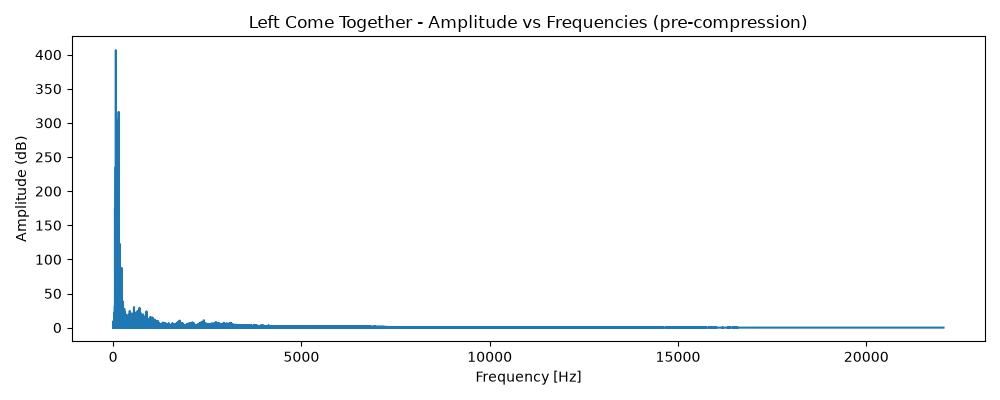

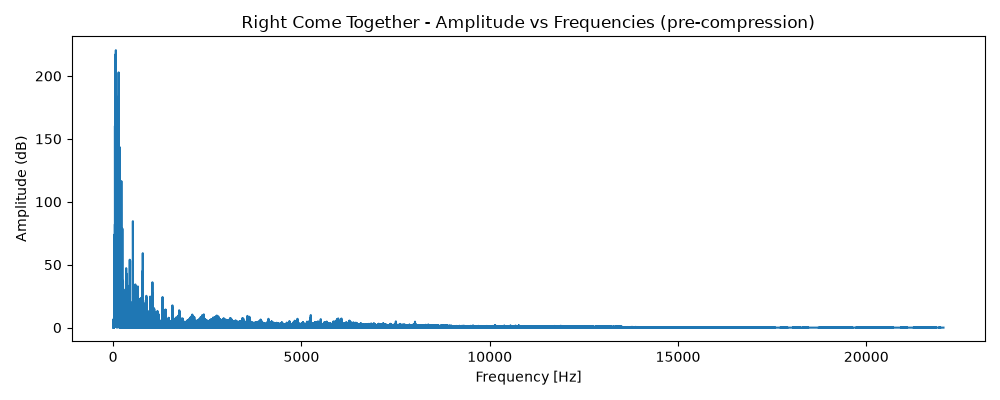

In [5]:
left_data, f_transform_left, f_left, amplitude_left, right_data, f_transform_right, f_right, amplitude_right, sample_rate = transform('come_together.wav')
plot(f_left, amplitude_left,  'Left Come Together - Amplitude vs Frequencies (pre-compression)', 'Frequency [Hz]', 'Amplitude (dB)')
plot(f_right,  amplitude_right,  'Right Come Together - Amplitude vs Frequencies (pre-compression)', 'Frequency [Hz]', 'Amplitude (dB)')

In [6]:
def remove_dc_offset(f_transform):
    f_transform[0] = 0
    amplitude = np.abs(f_transform) / len(f_transform)
    return amplitude, f_transform

In [7]:
def adjust_to_speaker_freqs(sample_rate, f_transform):
    #35Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_freq_index = int(35/delta_f)+1
    max_freq_index = int(20000/delta_f)+1

    f_transform[:min_freq_index] = 0
    #TBD, low pass filter
    # f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform

In [8]:
def adjust_to_iphone_freqs(sample_rate, f_transform):
    #200Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_freq_index = int(200/delta_f)+1
    max_freq_index = int(16000/delta_f)+1
    
    f_transform[:min_freq_index] = 0
    # f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform

In [9]:
def amplify_frequencies(sample_rate, f_transform):
    #200Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_freq_index = int(200/delta_f)+1
    
    for i in range(min_freq_index):
        f_transform[i] *= 2
    # f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform

In [10]:
def missing_fundamental(sample_rate, f_transform):
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_audible_index = int(20/delta_f)+1
    min_freq_index = int(200/delta_f)+1
    print(length)
    for i in range(min_audible_index, min_freq_index):
        #minimum harmonic that is >= min_freq_index
        n = math.ceil(200/(i*delta_f))
        n_index = n*i
        n_p1_index = (n+1)*i
        n_p2_index = (n+2)*i
        
        f_transform[n_index] += (f_transform[i] / (n))
        f_transform[n_p1_index] += (f_transform[i] / ((n+1)))
        f_transform[n_p2_index] += (f_transform[i] / ((n+2)))

    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform


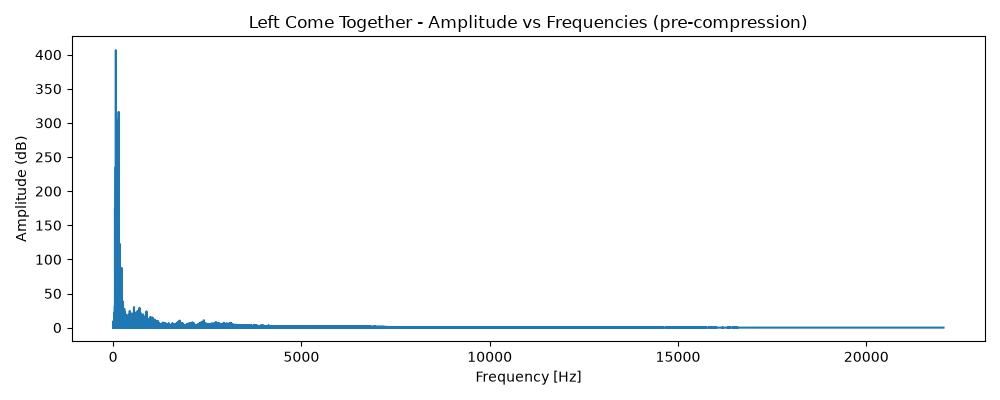

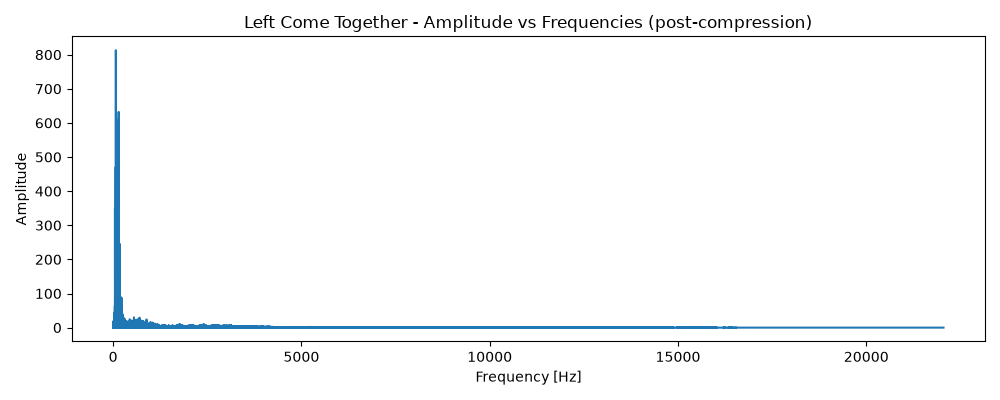

In [11]:
# al, ftl = missing_fundamental(sample_rate, f_transform_left)
# ar, ftr = missing_fundamental(sample_rate, f_transform_right)
# amplitude_left_new, f_transform_left_new = adjust_to_iphone_freqs(sample_rate, ftl)
# amplitude_right_new, f_transform_right_new = adjust_to_iphone_freqs(sample_rate, ftr)
amplitude_left_new, f_transform_left_new = amplify_frequencies(sample_rate, f_transform_left)
amplitude_right_new, f_transform_right_new = amplify_frequencies(sample_rate, f_transform_right)

plot(f_left, amplitude_left,  'Left Come Together - Amplitude vs Frequencies (pre-compression)', 'Frequency [Hz]', 'Amplitude (dB)')
plot(f_left, amplitude_left_new,  'Left Come Together - Amplitude vs Frequencies (post-compression)', 'Frequency [Hz]', 'Amplitude')

In [12]:
def inverse_transform(left, right, sample_rate, output_filename):
    reconstructed_left = irfft(left)
    reconstructed_right = irfft(right)
  
    reconstructed_real = np.stack((reconstructed_left, reconstructed_right), axis=1)
    audio_data_int16 = np.int16(np.clip(reconstructed_real, -32768, 32767))
    
    wavfile.write(output_filename, sample_rate, audio_data_int16)

    return audio_data_int16

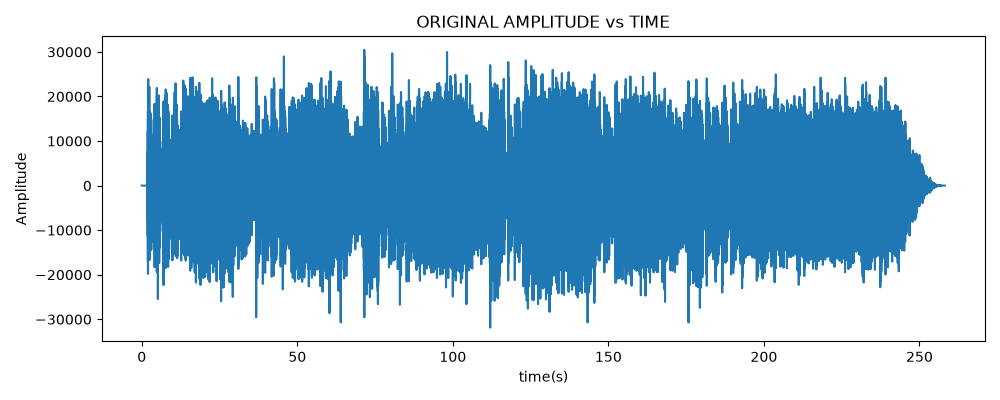

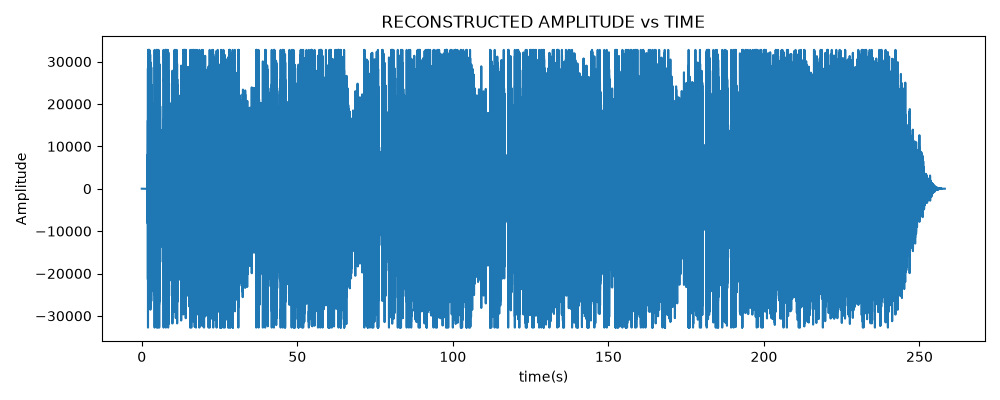

In [ ]:
# reconstructed_data = inverse_transform(f_transform_left_new, f_transform_right_new, sample_rate, 'come_together_with_harmonics_hi_pass.wav')
reconstructed_data = inverse_transform(f_transform_left_new, f_transform_right_new, sample_rate, 'come_together_amplified_lows.wav')
original_data = np.stack((left_data, right_data), axis=1)

# delta = reconstructed_data - original_data
# print(np.mean(np.abs(delta)))
# wavfile.write('delta.wav', sample_rate, delta)

reconstructed_ld = reconstructed_data[:, 0]

duration = len(original_data) / sample_rate
time = np.linspace(0.0, duration, num=len(original_data))

dbfs_ref = 32768.0
plot(time, left_data, 'ORIGINAL AMPLITUDE vs TIME', 'time(s)', 'Amplitude')
plot(time, reconstructed_ld, 'RECONSTRUCTED AMPLITUDE vs TIME', 'time(s)', 'Amplitude')